In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# przełączyć, jeśli nie działa
from bitalg.visualizer.main import Visualizer
# from visualizer.main import Visualizer

In [5]:
def draw_mesh(vertices, triangles):
    # Rysuje triangulację: krawędzie i wierzchołki (wierzchołki na czerwono).
    vis = Visualizer()
    line_segments = []

    for a, b, c in triangles:
        line_segments.append((vertices[a], vertices[b]))
        line_segments.append((vertices[b], vertices[c]))
        line_segments.append((vertices[c], vertices[a]))

    vis.add_line_segment(line_segments)
    vis.add_point(vertices, color='red')
    
    vis.show()

In [6]:
# Wierzchołki (x, y) — indeksy 0..6
points = [
    (0.0, 0.0),  # 0
    (1.0, 0.0),  # 1
    (2.0, 0.0),  # 2
    (0.0, 1.0),  # 3
    (1.0, 1.0),  # 4
    (2.0, 1.0),  # 5
    (1.0, 2.0),  # 6
]

# Trójkąty (a, b, c) — indeksy wierzchołków, CCW
triangles = [
    (0, 1, 4),
    (0, 4, 3),
    (1, 2, 5),
    (1, 5, 4),
    (3, 4, 6),
    (4, 5, 6),
]

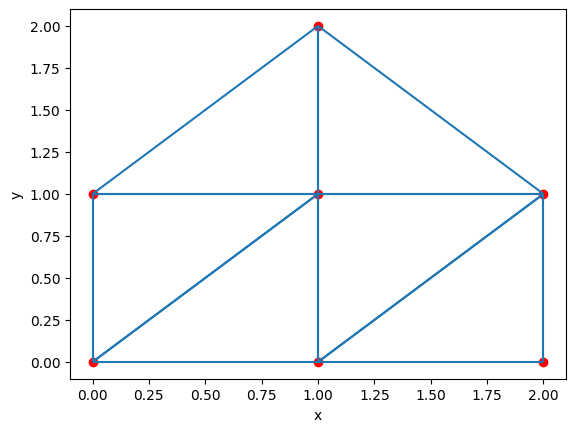

In [7]:
draw_mesh(points, triangles)

In [8]:
def save_mesh(file_path, points, indices):
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(f"{len(points)}\n")
        f.write(f"{len(indices)}\n")

        for x, y in points:
            f.write(f"{x} {y}\n")

        for a, b, c in indices:
            f.write(f"{a} {b} {c}\n")

In [9]:
def load_mesh(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        n = int(f.readline().strip())
        m = int(f.readline().strip())

        points = []
        for _ in range(n):
            x, y = f.readline().split()
            points.append((float(x), float(y)))

        indices = []
        for _ in range(m):
            a, b, c = f.readline().split()
            indices.append((int(a), int(b), int(c)))

    return points, indices


In [10]:
points_siatka, triangles_siatka = load_mesh("siatka.txt")

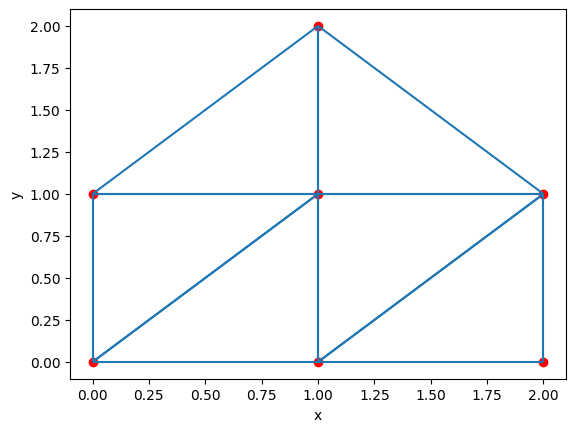

In [11]:
draw_mesh(points_siatka, triangles_siatka)

In [12]:
class HalfEdge:
    def __init__(self, origin : 'Vertex'=None, face : 'Face'=None, twin : 'HalfEdge'=None, next : 'HalfEdge'=None, prev : 'HalfEdge'=None):
        # Półkrawędź: przechowuje odniesienia do wierzchołka początkowego,
        # przynależnej ściany oraz sąsiednich półkrawędzi.
        self.origin = origin

        self.face = face

        self.twin = twin

        self.next = next
        self.prev = prev

    def __eq__(self, other : 'HalfEdge'):
        # Proste porównanie oparte na końcach (origin + next.origin).
        return self.origin == other.origin and self.next.origin == other.next.origin

    def __hash__(self):
        return hash(self.origin and self.next.origin)

In [13]:
class Vertex:
    def __init__(self, position : tuple[float], halfedge : HalfEdge = None, id : int = None):
        # Reprezentuje wierzchołek: pozycja 2D, jedna wychodząca półkrawędź i identyfikator.
        self.position = position

        # halfedge: dowolna półkrawędź wychodząca z tego wierzchołka
        self.halfedge = halfedge

        # id: indeks wierzchołka
        self.id = id

    def __add__(self, other):
        # Operacje wektorowe wygodne w kodzie wizualizacji.
        return (self.position[0] + other.position[0], self.position[1] + other.position[1])

    def __sub__(self, other):
        return (self.position[0] - other.position[0], self.position[1] - other.position[1])

    def __mul__(self, num):
        return (self.position[0] * num, self.position[1] * num)

    def __eq__(self, other):
        return self.id == other.id

    def __hash__(self):
        return hash(self.id)

In [14]:
class Face:
    def __init__(self, halfedge : HalfEdge=None, id : int=None):
        # Ściana (trójkąt) reprezentowana przez jedną półkrawędź należącą do niej.
        self.halfedge = halfedge
        self.id = id

In [15]:
class HalfEdgeDataStructure:
    def __init__(self, points, triangles):
        # Budowanie struktury half-edge z list punktów i trójkątów.
        self.vertices = [Vertex(pos, id=i) for i, pos in enumerate(points)]
        self.triangles = list(triangles)

        self.faces = []
        self.half_edges = []
        self.half_edges_dict = {}  # (u, v) -> HalfEdge u->v

        self._build_structure()
        self._build_boundary()

    def _pair_halfedge(self, u, v, edge):
        # Łączenie bliźniaczych półkrawędzi u->v i v->u, utrzymywanie mapy krawędzi bez bliźniaka.
        t = self.half_edges_dict.get((v, u))
        if t is not None:
            edge.twin = t
            t.twin = edge
            del self.half_edges_dict[(v, u)]
        else:
            self.half_edges_dict[(u, v)] = edge

    def _build_structure(self):
        # Tworzy wszystkie półkrawędzie i twarze na podstawie listy trójkątów.
        for idx, (a, b, c) in enumerate(self.triangles):
            face = Face(id=idx)

            edge_0 = HalfEdge(origin=self.vertices[a], face=face)
            edge_1 = HalfEdge(origin=self.vertices[b], face=face)
            edge_2 = HalfEdge(origin=self.vertices[c], face=face)

            edge_0.next, edge_1.next, edge_2.next = edge_1, edge_2, edge_0
            edge_0.prev, edge_1.prev, edge_2.prev = edge_2, edge_0, edge_1

            face.halfedge = edge_0

            if self.vertices[a].halfedge is None:
                self.vertices[a].halfedge = edge_0
            if self.vertices[b].halfedge is None:
                self.vertices[b].halfedge = edge_1
            if self.vertices[c].halfedge is None:
                self.vertices[c].halfedge = edge_2

            # łączenie bliźniaczych krawędzi/dodawanie krawędzi do mapy
            self._pair_halfedge(a, b, edge_0)
            self._pair_halfedge(b, c, edge_1)
            self._pair_halfedge(c, a, edge_2)

            self.faces.append(face)
            self.half_edges.extend([edge_0, edge_1, edge_2])

    def _build_boundary(self):
        # Tworzy brakujące (brzegowe) półkrawędzie i łączy je w pętlę brzegową.
        twinless_half_edges = list(self.half_edges_dict.values())

        new_boundary = []
        # tworzenie krawędzi na brzegach i łączenie ich z bliźniaczymi
        for edge in twinless_half_edges:
            u = edge.origin.id
            v = edge.next.origin.id

            b = HalfEdge(origin=self.vertices[v], face = None)
            b.twin = edge
            edge.twin = b

            new_boundary.append(b)

        # stworzenie mapy kolejnych połączeń dla krawędzi zewnętrznych
        incoming = {}
        for edge in twinless_half_edges:
            v = edge.next.origin.id
            incoming[v] = edge

        # łączenie następnych krawędzi zewnętrznych w pętlę
        for edge in twinless_half_edges:
            b = edge.twin
            u = edge.origin.id
            prev = incoming.get(u)
            b_next = prev.twin
            b.next = b_next
            b_next.prev = b

        self.half_edges.extend(new_boundary)

In [16]:
halfEdgeStructure = HalfEdgeDataStructure(points, triangles)

In [17]:
import math

def visualize_halfedge_structure(mesh : HalfEdgeDataStructure,
                                 draw_mesh_edges=True,
                                 draw_vertices=True,
                                 shrink=0.15,
                                 inward_offset=0.05):
    # Rysuje strukturę half-edge: rozróżnia krawędzie wewnętrzne i brzegowe,
    # przesuwa wewnętrzne ku środkowi trójkąta, dodaje krótkie wskaźniki.
    vis = Visualizer()

    def add(a, b): return (a[0] + b[0], a[1] + b[1])
    def sub(a, b): return (a[0] - b[0], a[1] - b[1])
    def mul(a, s): return (a[0] * s, a[1] * s)
    def dot(a, b): return a[0] * b[0] + a[1] * b[1]
    def length(v): return math.hypot(v[0], v[1])
    def norm(v):
        l = length(v)
        return (0.0, 0.0) if l == 0 else (v[0] / l, v[1] / l)

    # krawędzie triangulacji
    if draw_mesh_edges:
        verts_pos = [v.position for v in mesh.vertices]
        mesh_segments = []
        for a, b, c in mesh.triangles:
            mesh_segments.append((verts_pos[a], verts_pos[b]))
            mesh_segments.append((verts_pos[b], verts_pos[c]))
            mesh_segments.append((verts_pos[c], verts_pos[a]))
        vis.add_line_segment(mesh_segments)

    # wierzchołki
    if draw_vertices:
        vis.add_point([v.position for v in mesh.vertices], color='red')

    internal_segments, internal_tips = [], []
    boundary_segments, boundary_tips = [], []

    for he in mesh.half_edges:
        if he.next is None or he.origin is None:
            continue

        p0 = he.origin.position
        p1v = he.next.origin
        if p1v is None:
            continue
        p1 = p1v.position

        v = sub(p1, p0)
        L = length(v)
        if L == 0:
            continue

        # skrócenie odcinka
        start = add(p0, mul(v, shrink))
        end   = add(p0, mul(v, 1.0 - shrink))

        if he.face is None:
            # boundary: nie przesuwamy do wnętrza (bo nie ma ściany)
            boundary_segments.append((start, end))
            boundary_tips.append(end)
            continue

        # internal: przesuwamy do wnętrza trójkąta
        if he.prev is None:
            continue

        pa = he.origin.position
        pb = he.next.origin.position
        pc = he.prev.origin.position
        centroid = ((pa[0] + pb[0] + pc[0]) / 3.0, (pa[1] + pb[1] + pc[1]) / 3.0)

        n = norm((-v[1], v[0]))
        mid = ((p0[0] + p1[0]) / 2.0, (p0[1] + p1[1]) / 2.0)
        if dot(n, sub(centroid, mid)) < 0:
            n = (-n[0], -n[1])

        offset = inward_offset * L
        start_i = add(start, mul(n, offset))
        end_i   = add(end,   mul(n, offset))

        internal_segments.append((start_i, end_i))
        internal_tips.append(end_i)

    vis.add_line_segment(internal_segments)
    vis.add_point(internal_tips, color='blue')

    # boundary wyróżniamy kolorem końcówek
    vis.add_line_segment(boundary_segments)
    vis.add_point(boundary_tips, color='green')

    vis.show()


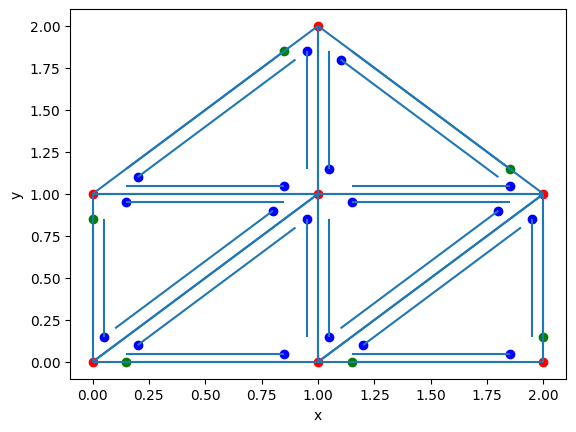

In [18]:
visualize_halfedge_structure(halfEdgeStructure)

In [19]:
big_mesh = load_mesh("big_siatka.txt")
big_mesh_points, big_mesh_triangles = big_mesh
big_mesh_structure = HalfEdgeDataStructure(big_mesh[0], big_mesh[1])

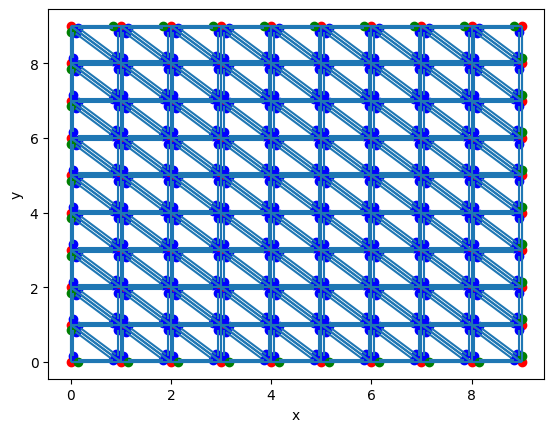

In [20]:
visualize_halfedge_structure(big_mesh_structure)

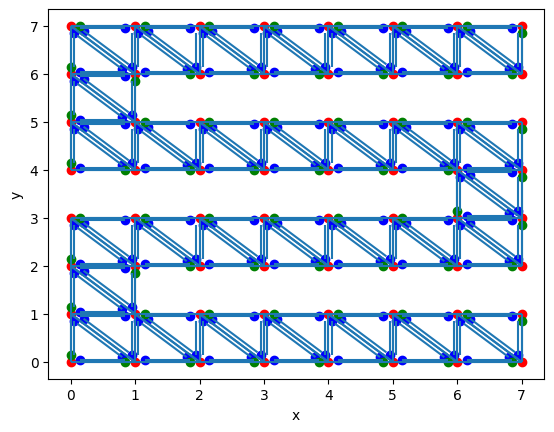

In [21]:
pasek_points, pasek_triangles = load_mesh('pasek.txt')
pasek_structure = HalfEdgeDataStructure(pasek_points, pasek_triangles)
visualize_halfedge_structure(pasek_structure)

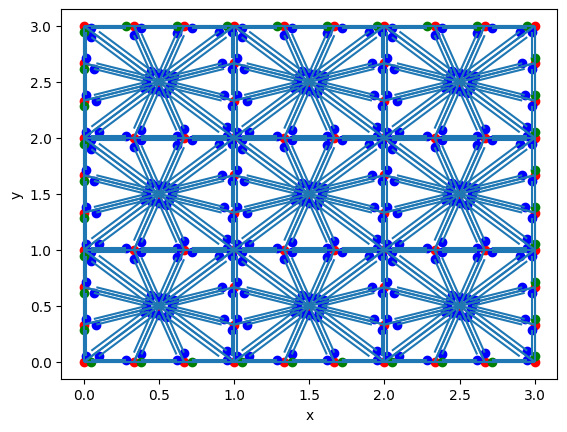

In [22]:
points_gwiazdy, triangles_gwiazdy = load_mesh('gwiazdy.txt')
gwiazdy_structure = HalfEdgeDataStructure(points_gwiazdy, triangles_gwiazdy)
visualize_halfedge_structure(gwiazdy_structure)
# draw_mesh(points_gwiazdy, triangles_gwiazdy)

# Operacje na siatce trójkątnej
### 1. Wyznaczanie otoczenia dla wybranego wierzchołka
### 2. Wyznaczanie otoczenia dla wybranego trójkąta
### 3. Przeglądanie incydentnych trójkątów od wybranego trójkąta w kierunku wybranego punktu

## Operacje dla list

In [23]:
def draw_triangle_list(vis : Visualizer, points, triangle, color='green'):
    vis.add_point([points[idx] for idx in triangle], color=color)
    vis.add_line_segment((points[triangle[0]], points[triangle[1]]), color=color)
    vis.add_line_segment((points[triangle[1]], points[triangle[2]]), color=color)
    vis.add_line_segment((points[triangle[2]], points[triangle[0]]), color=color)

In [24]:
def visit_point_list(points, triangles, point_idx, vis : Visualizer = None):
    visited = set()

    for triangle in triangles:
        if point_idx in triangle:
            visited.update(triangle)
            if vis is not None:
                draw_triangle_list(vis, points, triangle, color='red')

    return visited, vis

In [25]:
def find_surrounding_points_list(points, triangles, point_idx, layers=1):
    # budujemy graf: idx -> zbiór sąsiadów
    connections = {}

    for p1, p2, p3 in triangles:
        for p in [p1, p2, p3]:
            if p not in connections:
                connections[p] = set()
        connections[p1].add(p2)
        connections[p1].add(p3)
        connections[p2].add(p1)
        connections[p2].add(p3)
        connections[p3].add(p1)
        connections[p3].add(p2)

    output = [[point_idx]]

    # Odwiedzanie kolejnych warstw
    current_layer = {point_idx}
    all_visited = {point_idx}

    for _ in range(layers):
        output.append([])

        next_layer = set()
        for idx in current_layer:
            for new_idx in connections[idx]:
                if new_idx not in all_visited:
                    # Zbieramy punkty do kolejnej warstwy
                    next_layer.add(new_idx)
                    all_visited.add(new_idx)

        current_layer = next_layer
        for idx in current_layer:
            output[-1].append(idx)

    return output

In [26]:
find_surrounding_points_list(points, triangles, 1, 2)

[[1], [0, 2, 4, 5], [3, 6]]

In [27]:
def visualize_surrounding_points_list(points, triangles, point_idx, layers=1, show_gif=False):
    vis = Visualizer()
    vis.add_point(points)

    # budujemy graf: idx -> zbiór sąsiadów i idx_punktu -> idx_trójkąta (dla wizualizacji)
    connections = {}
    point_to_tris = {}

    for tri in triangles:
        for p in tri:
            if p not in connections: connections[p] = set()
            if p not in point_to_tris: point_to_tris[p] = []
            point_to_tris[p].append(tri)

        p1, p2, p3 = tri
        connections[p1].update([p2, p3])
        connections[p2].update([p1, p3])
        connections[p3].update([p1, p2])

    # Odwiedzanie warstw z rysowaniem krawędzi
    current_layer = {point_idx}
    all_visited = {point_idx}

    for _ in range(layers):
        next_layer = set()
        for idx in current_layer:
            # Pobieramy trójkąty z mapy, co zastępuje powolne visit_point_list
            for tri in point_to_tris.get(idx, []):
                draw_triangle_list(vis, points, tri, color='red')

            # Szukamy sąsiadów do kolejnej warstwy
            for neighbor in connections.get(idx, []):
                if neighbor not in all_visited:
                    all_visited.add(neighbor)
                    next_layer.add(neighbor)

        current_layer = next_layer

    vis.add_point(points[point_idx], color='green')

    if show_gif:
        vis.show_gif(interval=200)
    else:
        vis.show()

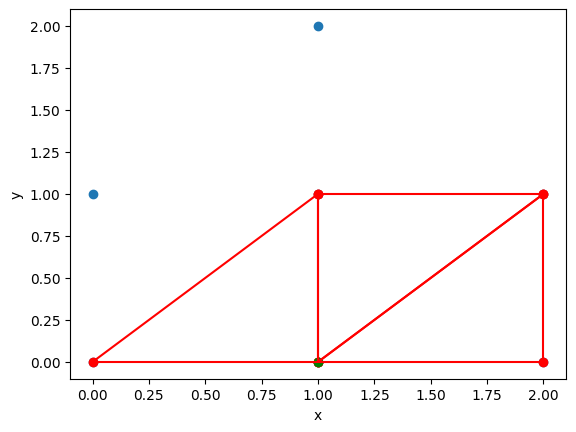

In [28]:
visualize_surrounding_points_list(points, triangles, 1)

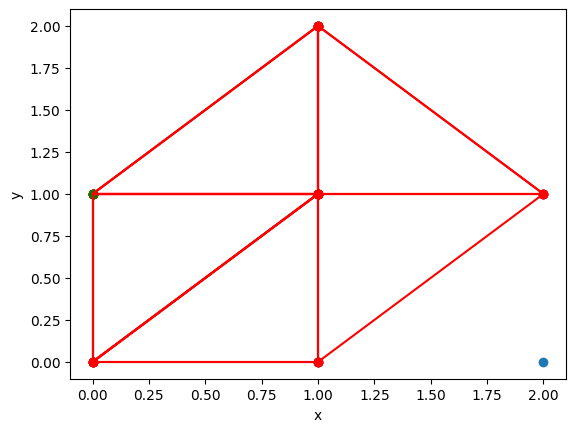

In [29]:
visualize_surrounding_points_list(points, triangles, 3, 2)

In [30]:
def visit_triangle_list(points, triangles, tri_idx, vis : Visualizer = None):
    triangle = triangles[tri_idx]
    # Wyciągamy krawędzie trójkąta (znormalizowane, by kolejność nie miała znaczenia)
    edges = []
    for i in range(3):
        p1, p2 = triangle[i], triangle[(i+1)%3]
        edges.append((p1, p2) if p1 < p2 else (p2, p1))

    if vis is not None:
        draw_triangle_list(vis, points, triangle, 'red')

    return edges, vis

In [31]:
def find_surrounding_triangles_list(points, triangles, start_tri_idx, layers=1):
    # Budujemy mapę krawędź -> lista indeksów trójkątów przyległych
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        for i in range(3):
            p1, p2 = tri[i], tri[(i+1)%3]
            edge = (p1, p2) if p1 < p2 else (p2, p1)
            if edge not in edge_to_tri:
                edge_to_tri[edge] = []
            edge_to_tri[edge].append(idx)

    output = [[triangles[start_tri_idx]]]
    current_layer = {start_tri_idx}
    all_visited = {start_tri_idx}

    for _ in range(layers):
        next_layer = set()
        layer_triangles = []

        for tri_idx in current_layer:
            # Pobieramy krawędzie aktualnego trójkąta
            edges, _ = visit_triangle_list(points, triangles, tri_idx)

            for e in edges:
                neighbors = edge_to_tri.get(e, [])
                for n_idx in neighbors:
                    if n_idx not in all_visited:
                        all_visited.add(n_idx)
                        next_layer.add(n_idx)
                        layer_triangles.append(triangles[n_idx])

        output.append(layer_triangles)
        current_layer = next_layer

    return output

In [32]:
print(find_surrounding_triangles_list(points, triangles, 1, 2))

[[(0, 4, 3)], [(0, 1, 4), (3, 4, 6)], [(1, 5, 4), (4, 5, 6)]]


In [33]:
def visualize_surrounding_triangles_list(points, triangles, start_tri_idx, layers=1, show_gif=False):
    vis = Visualizer()
    vis.add_point(points)

    # Budujemy mapę krawędź -> lista indeksów trójkątów przyległych
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        for i in range(3):
            p1, p2 = tri[i], tri[(i+1)%3]
            edge = (p1, p2) if p1 < p2 else (p2, p1)
            if edge not in edge_to_tri:
                edge_to_tri[edge] = []
            edge_to_tri[edge].append(idx)


    current_layer = {start_tri_idx}
    all_visited = {start_tri_idx}

    for _ in range(layers):
        next_layer = set()
        for tri_idx in current_layer:
            # Sprawdzamy krawędzie trójkątów w bieżącej warstwie
            current_tri = triangles[tri_idx]
            for i in range(3):
                p1, p2 = current_tri[i], current_tri[(i+1)%3]
                edge = (p1, p2) if p1 < p2 else (p2, p1)

                # Pobieramy sąsiadów przez krawędź
                for n_idx in edge_to_tri.get(edge, []):
                    if n_idx not in all_visited:
                        all_visited.add(n_idx)
                        next_layer.add(n_idx)
                        draw_triangle_list(vis, points, triangles[n_idx], color='red')

        current_layer = next_layer

    draw_triangle_list(vis, points, triangles[start_tri_idx])

    if show_gif:
        vis.show_gif(interval=200)
    else:
        vis.show()

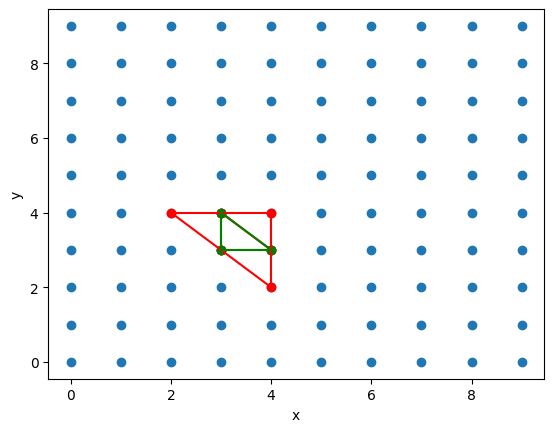

In [34]:
visualize_surrounding_triangles_list(big_mesh[0], big_mesh[1], 60)

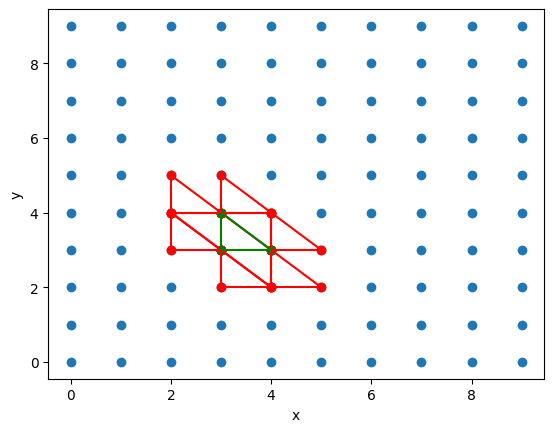

In [35]:
visualize_surrounding_triangles_list(big_mesh[0], big_mesh[1], 60, 2)

In [36]:
def orientation(a, b, c, eps=1e-12):
    # Zwraca 1 jeśli punkt c leży po lewej stronie wektora a->b,
    # -1 jeśli po prawej, 0 jeśli kolinearne (z tolerancją eps).
    det = (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])
    if abs(det) <= eps:
        return 0
    return 1 if det > 0 else -1

In [37]:
def check_point_in_triangle_list(points, triangles, tri_idx, point_to_check):
    # Sprawdza czy dany punkt leży wewnątrz trójkąta (orientacje spójne).
    tri = triangles[tri_idx]
    p1, p2, p3 = points[tri[0]], points[tri[1]], points[tri[2]]

    o1 = orientation(p1, p2, point_to_check)
    o2 = orientation(p2, p3, point_to_check)
    o3 = orientation(p3, p1, point_to_check)
    return (o1 >= 0 and o2 >= 0 and o3 >= 0)

In [38]:
from collections import deque

def find_point_in_mesh_list(points, triangles, start_tri_idx, end_point):
    # Szukanie trójkąta zawierającego punkt:
    # najpierw "na wprost" (krok po krawędzi), jeśli to się nie uda — BFS
    # Mapa trójkąt -> lista krawędzi skierowanych, tzn. idąc za indeksami końców krawędzi idziemy CCW
    tri_to_edges = {}
    # Mapa krawędź skierowana -> indeks trójkąta
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        i1, i2, i3 = tri
        if orientation(points[i1], points[i2], points[i3]) < 0:
            # jeśli są CW, zamień dwa wierzchołki, żeby stały się CCW
            triangles[idx] = (i1, i3, i2)
        # dodajemy krawędzie w kolejności CCW: (a,b), (b,c), (c,a)
        a, b, c = triangles[idx]
        edges = [(a, b), (b, c), (c, a)]
        tri_to_edges[idx] = edges
        for edge in edges:
            edge_to_tri[edge] = idx

    # próbujemy przejść do punktu bezpośrednio, jeśli nie to się nie powiedzie, używamy BFS
    curr_tri_idx = start_tri_idx
    visited_triangles = set()

    while True:
        if curr_tri_idx in visited_triangles:
            break   # cykl
        visited_triangles.add(curr_tri_idx)

        next_edge = None
        if check_point_in_triangle_list(points, triangles, curr_tri_idx, end_point):
            return curr_tri_idx
        for edge in tri_to_edges[curr_tri_idx]:
            # szukamy krawędzi, po prawej której leży punkt
            if orientation(points[edge[0]], points[edge[1]], end_point) < 0:
                next_edge = (edge[1], edge[0])
                break

        if next_edge not in edge_to_tri:
            break       # nie istnieje kolejny trójkąt w siatce, potencjalnie jest tam dziura
        curr_tri_idx = edge_to_tri[next_edge]

    # BFS od ostatniego punktu
    queue = deque([curr_tri_idx])
    visited_triangles = set()

    while queue:
        curr_triangle_idx = queue.popleft()
        if curr_triangle_idx in visited_triangles:
            continue
        visited_triangles.add(curr_triangle_idx)

        if check_point_in_triangle_list(points, triangles, curr_triangle_idx, end_point):
            return curr_triangle_idx

        for edge in tri_to_edges[curr_triangle_idx]:
            # krawędź przeciwna do obecnej prowadzi do kolejnego trójkąta
            # jeśli istnieje to ma ona swój trójkąt
            next_edge = (edge[1], edge[0])
            if next_edge in edge_to_tri:
                queue.append(edge_to_tri[next_edge])

    return -1

In [39]:
def visualize_point_in_mesh_list(points, triangles, start_tri_idx, end_point, show_gif=False):
    # Wizualizacja procesu szukania punktu: rysuje odwiedzane trójkąty i wynik.
    vis = Visualizer()
    vis.add_point(points)

    # Mapa trójkąt -> lista krawędzi skierowanych, tzn. idąc za indeksami końców krawędzi idziemy CCW
    tri_to_edges = {}
    # Mapa krawędź skierowana -> indeks trójkąta
    edge_to_tri = {}

    for idx, tri in enumerate(triangles):
        i1, i2, i3 = tri
        if orientation(points[i1], points[i2], points[i3]) < 0:
            # jeśli są CW, zamień dwa wierzchołki, żeby stały się CCW
            triangles[idx] = (i1, i3, i2)
        # dodajemy krawędzie w kolejności CCW: (a,b), (b,c), (c,a)
        a, b, c = triangles[idx]
        edges = [(a, b), (b, c), (c, a)]
        tri_to_edges[idx] = edges
        for edge in edges:
            edge_to_tri[edge] = idx

    # próbujemy przejść do punktu bezpośrednio, jeśli nie to się nie powiedzie, używamy BFS
    curr_tri_idx = start_tri_idx
    visited_triangles = set()

    while True:
        if curr_tri_idx in visited_triangles:
            break   # cykl
        visited_triangles.add(curr_tri_idx)

        draw_triangle_list(vis, points, triangles[curr_tri_idx], color='red')

        next_edge = None
        if check_point_in_triangle_list(points, triangles, curr_tri_idx, end_point):
            draw_triangle_list(vis, points, triangles[start_tri_idx])
            vis.add_point(end_point, color='green')

            if show_gif:
                vis.show_gif(interval=200)
            else:
                vis.show()
            return

        for edge in tri_to_edges[curr_tri_idx]:
            # szukamy krawędzi, po prawej której leży punkt
            if orientation(points[edge[0]], points[edge[1]], end_point) < 0:
                next_edge = (edge[1], edge[0])
                break

        if next_edge not in edge_to_tri:
            break   # nie istnieje kolejny trójkąt w siatce, potencjalnie jest tam dziura
        curr_tri_idx = edge_to_tri[next_edge]

    queue = deque([start_tri_idx])
    visited_triangles = set()

    while queue:
        curr_triangle_idx = queue.popleft()
        if curr_triangle_idx in visited_triangles:
            continue
        visited_triangles.add(curr_triangle_idx)

        draw_triangle_list(vis, points, triangles[curr_triangle_idx], color='red')

        if check_point_in_triangle_list(points, triangles, curr_triangle_idx, end_point):
            break

        for edge in tri_to_edges[curr_triangle_idx]:
            # krawędź przeciwna do obecnej prowadzi do kolejnego trójkąta
            # jeśli istnieje to ma ona swój trójkąt
            next_edge = (edge[1], edge[0])
            if next_edge in edge_to_tri:
                queue.append(edge_to_tri[next_edge])

    draw_triangle_list(vis, points, triangles[start_tri_idx])
    vis.add_point(end_point, color='green')

    if show_gif:
        vis.show_gif(interval=200)
    else:
        vis.show()

In [40]:
print(find_point_in_mesh_list(points, triangles, 0, (1.25, 1.25)))

5


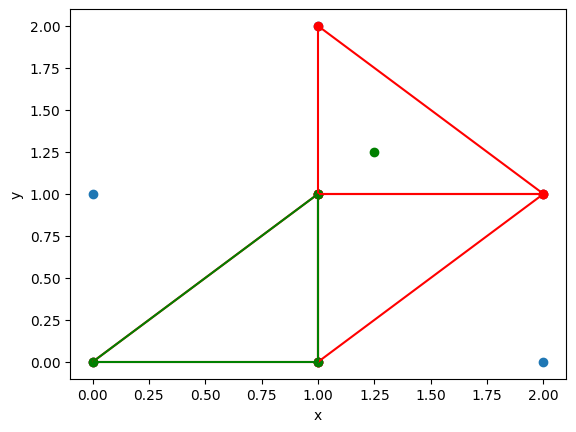

In [41]:
visualize_point_in_mesh_list(points, triangles, 0, (1.25, 1.25))

In [42]:
print(find_point_in_mesh_list(big_mesh[0], big_mesh[1], 0, (2.5, 1.25)))

22


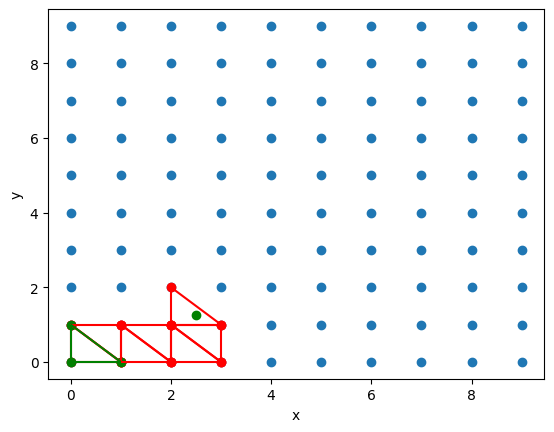

In [43]:
visualize_point_in_mesh_list(big_mesh[0], big_mesh[1], 0, (2.5, 1.25))

In [44]:
print(find_point_in_mesh_list(pasek_points, pasek_triangles, 13, (6.5, 6.75)))

61


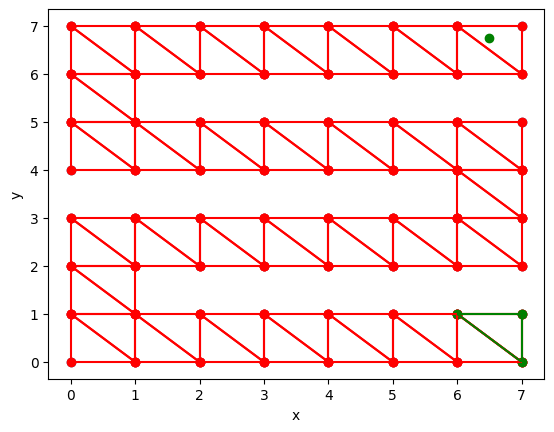

In [45]:
visualize_point_in_mesh_list(pasek_points, pasek_triangles, 13, (6.5, 6.75))

## Operacje dla struktury Half Edge Data Structure

In [48]:
def draw_triangle_structure(face_edges: list[HalfEdge], vis: Visualizer, color='green'):
    vis.add_point([edge.origin.position for edge in face_edges], color=color)
    vis.add_line_segment((face_edges[0].origin.position, face_edges[1].origin.position), color=color)
    vis.add_line_segment((face_edges[1].origin.position, face_edges[2].origin.position), color=color)
    vis.add_line_segment((face_edges[2].origin.position, face_edges[0].origin.position), color=color)

In [49]:
def visit_point_structure(point: Vertex, vis: Visualizer):
    # Odwiedza sąsiednie trójkąty wokół wierzchołka używając pól half-edge.
    visited = set()
    visited.add(point)

    if vis is not None:
        vis.add_point(point.position, color='red')

    curr_edge = point.halfedge
    # przechodzimy po wszystkich ścianach wokół punktu
    while curr_edge is not None:
        if curr_edge.face is not None:
            # Rysujemy wszystkie 3 boki trójkąta, do którego należy curr
            edges_in_face = [curr_edge, curr_edge.next, curr_edge.prev]
            visited.update([edge.origin for edge in edges_in_face])
            if vis is not None:
                draw_triangle_structure(edges_in_face, vis, color='red')

        # sprawdzamy, czy istnieje kolejna ściana
        curr_edge = curr_edge.twin.next if curr_edge.twin else None
        # sprawdziliśmy wszystko
        if curr_edge == point.halfedge:
            break

    return visited, vis

In [50]:
def find_surrounding_points_structure(structure: HalfEdgeDataStructure, start_pt_idx, layers=1):
    # Buduje warstwy sąsiednich punktów używając half-edge (szybciej niż lista).
    starting_vertex = structure.vertices[start_pt_idx]

    # Zawiera listy indeksów punktów w kolejnych warstwach, lista 0 - punkt startowy, lista 1 - pierwsza warstwa, itd.
    output = [[starting_vertex.id]]

    # Odwiedzanie kolejnych warstw
    current_layer = {starting_vertex}
    all_visited = {starting_vertex}

    for i in range(layers):
        output.append([])

        next_layer = set()
        for point in current_layer:
            neighbours, _ = visit_point_structure(point, None)
            for new_point in neighbours:
                if new_point not in all_visited:
                    # Zbieramy punkty do kolejnej warstwy
                    next_layer.add(new_point)
                    all_visited.add(new_point)

        current_layer = next_layer
        for point in current_layer:
            output[i+1].append(point.id)

    return output

In [51]:
print(find_surrounding_points_structure(halfEdgeStructure, 1, 2))

[[1], [0, 2, 4, 5], [3, 6]]


In [52]:
def visualize_surrounding_points_structure(structure: HalfEdgeDataStructure, start_pt_idx, layers=1, show_gif=False):
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    starting_vertex = structure.vertices[start_pt_idx]

    # Odwiedzanie kolejnych warstw
    current_layer = {starting_vertex}
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for point in current_layer:
            if point not in all_visited:
                new_visited, vis = visit_point_structure(point, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(point)

        current_layer = next_layer - all_visited

    vis.add_point(starting_vertex.position, color='green')

    if show_gif:
        vis.show_gif(interval=200)
    else:
        vis.show()

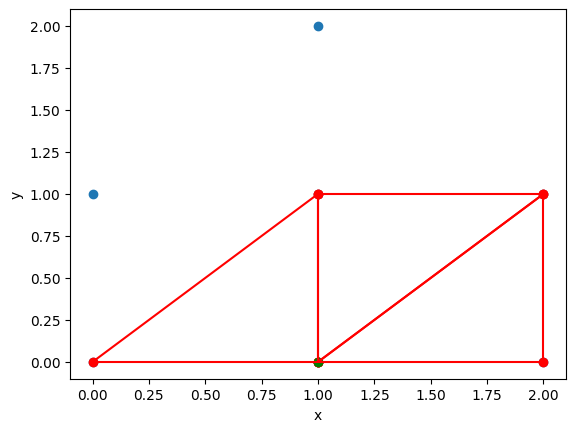

In [53]:
visualize_surrounding_points_structure(halfEdgeStructure, 1)

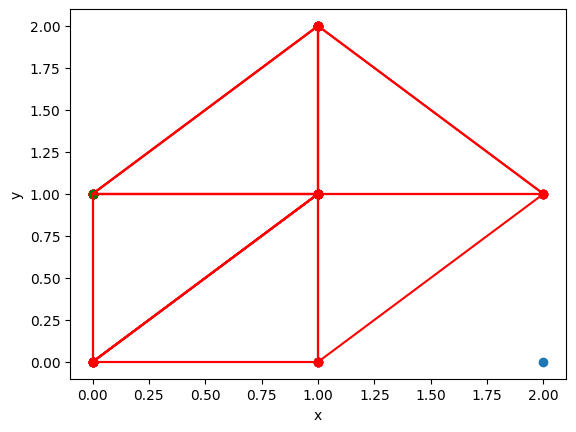

In [54]:
visualize_surrounding_points_structure(halfEdgeStructure, 3, 2)

In [56]:
# "odwiedza" trójkąt przyległy do zadanej krawędzi
def visit_edge_structure(edge: HalfEdge, vis: Visualizer):
    # Odwiedza trójkąt należący do danej półkrawędzi (edge, edge.next, edge.prev).
    visited = [edge, edge.next, edge.prev]
    if vis is not None:
        draw_triangle_structure(visited, vis, 'red')

    return visited, vis

In [57]:
def find_surrounding_triangles_structure(structure: HalfEdgeDataStructure, start_tri_idx, layers=1):
    # Szuka sąsiednich trójkątów warstwami poprzez półkrawędzie i ich bliźniaki.
    starting_face = structure.faces[start_tri_idx]

    edge_in_face = starting_face.halfedge
    face_edges = [edge_in_face, edge_in_face.next, edge_in_face.prev]

    output = [[edge.origin.id for edge in face_edges]]

    # Śledzimy odwiedzone ściany, by nie przetwarzać tego samego trójkąta dwa razy
    all_visited_faces = {starting_face}
    current_layer = set(face_edges)

    for i in range(layers):
        output.append([])

        next_layer = set()
        for edge in current_layer:
            neighbor = edge.twin
            if neighbor and neighbor.face and neighbor.face not in all_visited_faces:
                all_visited_faces.add(neighbor.face)
                new_edges, _ = visit_edge_structure(neighbor, None)

                # Zbieramy krawędzie do kolejnej warstwy
                next_layer.update(new_edges)
                output[i+1].append([edge.origin.id for edge in new_edges])

        current_layer = next_layer

    return output

In [58]:
print(find_surrounding_triangles_structure(halfEdgeStructure, 1, 2))

[[0, 4, 3], [[3, 4, 6], [4, 0, 1]], [[4, 1, 5], [6, 4, 5]]]


In [59]:
def visualize_surrounding_triangles_structure(structure: HalfEdgeDataStructure, start_tri_idx, layers=1, show_gif=False):
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    starting_face = structure.faces[start_tri_idx]

    edge_in_face = starting_face.halfedge
    face_edges = [edge_in_face, edge_in_face.next, edge_in_face.prev]

    # Śledzimy odwiedzone ściany, by nie przetwarzać tego samego trójkąta dwa razy
    all_visited_faces = {starting_face}
    current_layer = set(face_edges)

    for _ in range(layers):
        next_layer = set()
        for edge in current_layer:
            # Sprawdzamy, czy za krawędzią jest sąsiad i czy jego ściana nie była już odwiedzona
            neighbor = edge.twin
            if neighbor is not None and neighbor.face is not None and neighbor.face not in all_visited_faces:
                new_visited, vis = visit_edge_structure(neighbor, vis)

                all_visited_faces.add(neighbor.face)
                next_layer.update(new_visited)

        current_layer = next_layer

    draw_triangle_structure(face_edges, vis)

    if show_gif:
        vis.show_gif(interval=200)
    else:
        vis.show()

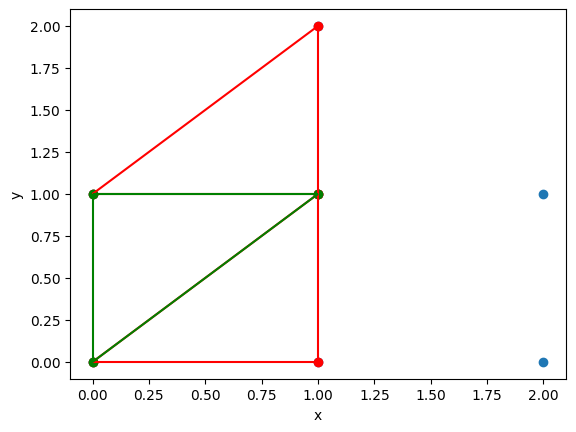

In [60]:
visualize_surrounding_triangles_structure(halfEdgeStructure, 1)

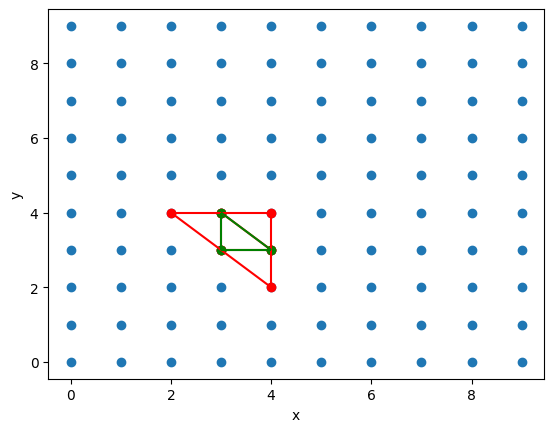

In [61]:
visualize_surrounding_triangles_structure(big_mesh_structure, 60)

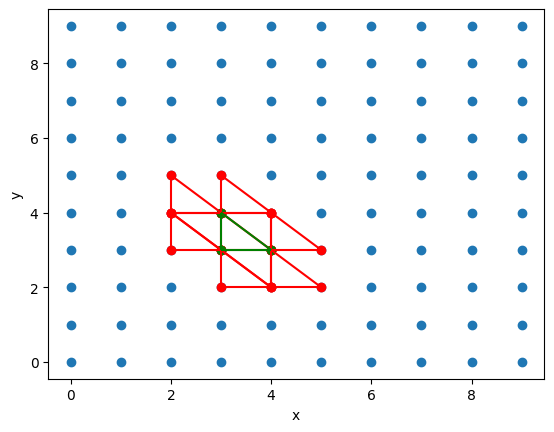

In [62]:
visualize_surrounding_triangles_structure(big_mesh_structure, 60, 2)

In [63]:
def check_point_in_triangle_structure(face: Face, point_to_check):
    # Sprawdza, czy punkt leży w trójkącie reprezentowanym przez face (orientacja względna).
    edge = face.halfedge
    p1, p2, p3 = edge.prev.origin.position, edge.origin.position, edge.next.origin.position
    o1 = orientation(p1, p2, point_to_check)
    o2 = orientation(p2, p3, point_to_check)
    o3 = orientation(p3, p1, point_to_check)

    return (o1 >= 0 and o2 >= 0 and o3 >= 0) or (o1 <= 0 and o2 <= 0 and o3 <= 0)

In [64]:
def find_point_in_mesh_structure(structure : HalfEdgeDataStructure, start_tri_idx, end_point):
    # Szukanie punktu podobnie jak w wersji listowej, ale operując na strukturze half-edge.
    # najpierw przejście "na wprost", potem BFS przez sąsiadujące ściany.
    starting_face = structure.faces[start_tri_idx]
    visited_faces = set()

    curr_face = starting_face
    while True:
        if curr_face in visited_faces:
            break   # cykl
        visited_faces.add(curr_face)

        if check_point_in_triangle_structure(curr_face, end_point):
            return curr_face.id

        edges = [curr_face.halfedge.prev, curr_face.halfedge, curr_face.halfedge.next]

        face_orient = orientation(edges[0].origin.position, edges[1].origin.position, edges[2].origin.position)

        next_edge = None
        for edge in edges:
            p1 = edge.origin.position
            p2 = edge.next.origin.position

            if face_orient * orientation(p1, p2, end_point) < 0:
                if edge.twin is not None and edge.twin.face is not None:
                    next_edge = edge.twin
                    break
        if next_edge is None or next_edge.face is None:
            break
        curr_face = next_edge.face

    # BFS
    queue = deque([curr_face])
    visited_faces = set()

    while queue:
        curr_face = queue.popleft()
        if curr_face in visited_faces:
            continue
        visited_faces.add(curr_face)

        if check_point_in_triangle_structure(curr_face, end_point):
            return curr_face.id

        edge = curr_face.halfedge
        if edge.twin and edge.twin.face:
            queue.append(edge.twin.face)
        if edge.next.twin and edge.next.twin.face:
            queue.append(edge.next.twin.face)
        if edge.prev.twin and edge.prev.twin.face:
            queue.append(edge.prev.twin.face)

    return -1

In [65]:
def visualize_point_in_mesh_structure(structure : HalfEdgeDataStructure, start_tri_idx, end_point, show_gif=False):
    # Wizualizacja szukania punktu korzystającego z half-edge.
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    starting_face = structure.faces[start_tri_idx]
    visited_faces = set()

    # analogicznie jak w wersji z listami, najpierw próbujemy przejść "na wprost", a jeśli się nie uda używamy BFS
    curr_face = starting_face
    while True:
        if curr_face in visited_faces:
            break   # cykl
        visited_faces.add(curr_face)

        edges = [curr_face.halfedge.prev, curr_face.halfedge, curr_face.halfedge.next]
        draw_triangle_structure(edges, vis, 'red')

        if check_point_in_triangle_structure(curr_face, end_point):
            edge = starting_face.halfedge
            draw_triangle_structure([edge.prev, edge, edge.next], vis)
            vis.add_point(end_point, color='green')

            if show_gif:
                vis.show_gif(interval=200)
            else:
                vis.show()

            return

        face_orient = orientation(edges[0].origin.position, edges[1].origin.position, edges[2].origin.position)

        next_edge = None
        for edge in edges:
            p1 = edge.origin.position
            p2 = edge.next.origin.position

            if face_orient * orientation(p1, p2, end_point) < 0:
                if edge.twin is not None and edge.twin.face is not None:
                    next_edge = edge.twin
                    break
        if next_edge is None or next_edge.face is None:
            break
        curr_face = next_edge.face

    # BFS
    queue = deque([curr_face])
    visited_faces = set()

    while queue:
        curr_face = queue.popleft()
        if curr_face in visited_faces:
            continue
        visited_faces.add(curr_face)

        draw_triangle_structure([curr_face.halfedge.prev, curr_face.halfedge, curr_face.halfedge.next], vis, 'red')

        if check_point_in_triangle_structure(curr_face, end_point):
            break

        if curr_face.halfedge.twin and curr_face.halfedge.twin.face:
            queue.append(curr_face.halfedge.twin.face)
        if curr_face.halfedge.next.twin and curr_face.halfedge.next.twin.face:
            queue.append(curr_face.halfedge.next.twin.face)
        if curr_face.halfedge.prev.twin and curr_face.halfedge.prev.twin.face:
            queue.append(curr_face.halfedge.prev.twin.face)

    edge = starting_face.halfedge
    draw_triangle_structure([edge.prev, edge, edge.next], vis)
    vis.add_point(end_point, color='green')

    if show_gif:
        vis.show_gif(interval=200)
    else:
        vis.show()

In [66]:
print(find_point_in_mesh_structure(big_mesh_structure, 0, (2.5, 1.25)))

22


In [67]:
print(find_point_in_mesh_structure(pasek_structure, 13, (6.5, 6.75)))

61


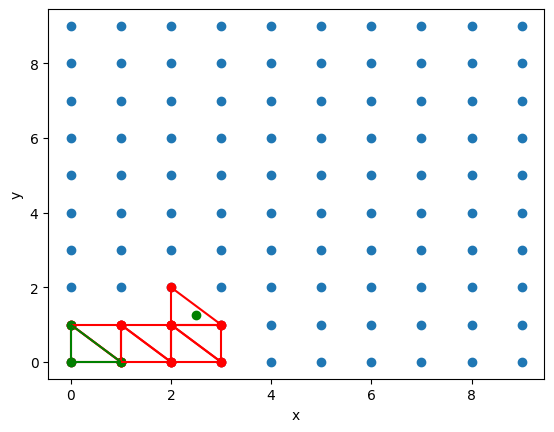

In [68]:
visualize_point_in_mesh_structure(big_mesh_structure, 0, (2.5, 1.25))

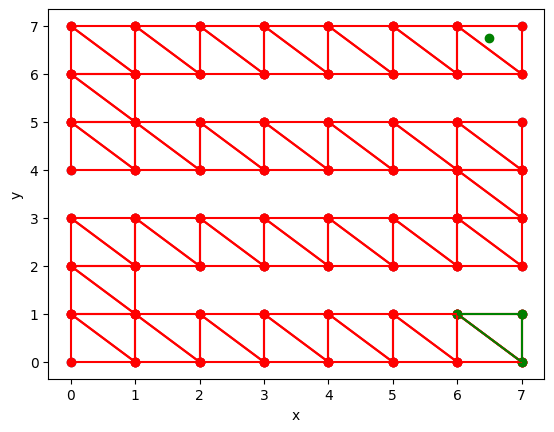

In [69]:
visualize_point_in_mesh_structure(pasek_structure, 13, (6.5, 6.75))

# Wizualizacje

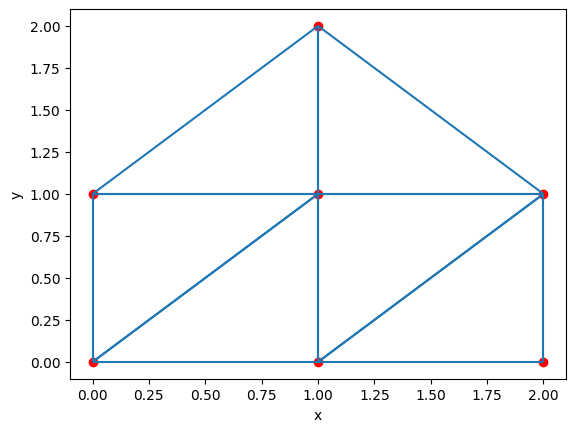

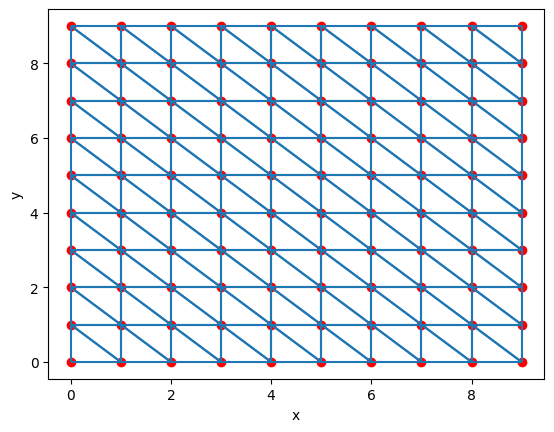

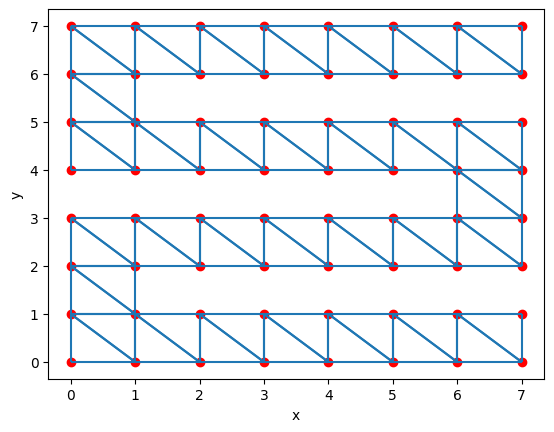

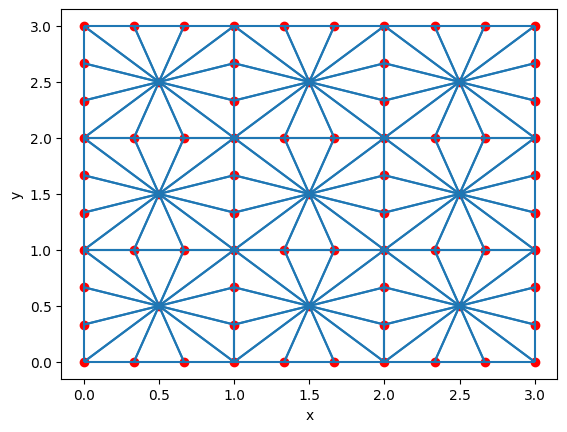

In [70]:
for file in ['siatka.txt', 'big_siatka.txt', 'pasek.txt', 'gwiazdy.txt']:
    points, triangles = load_mesh(file)
    draw_mesh(points, triangles)

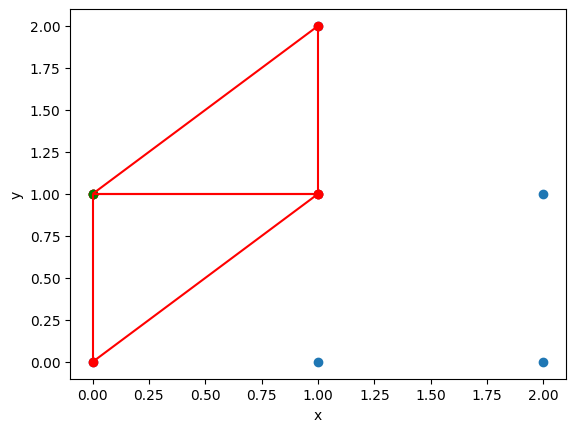

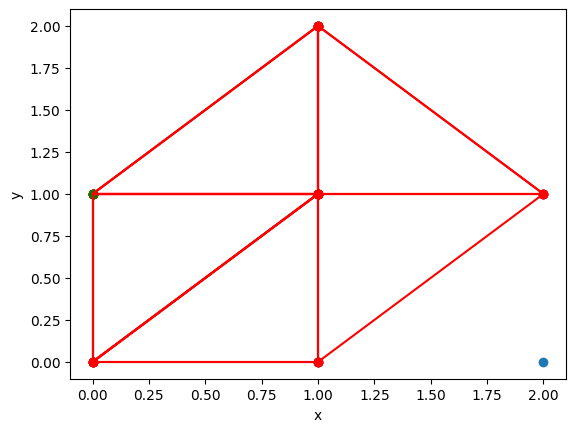

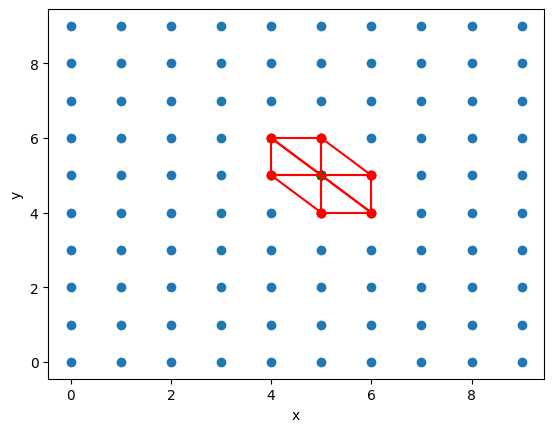

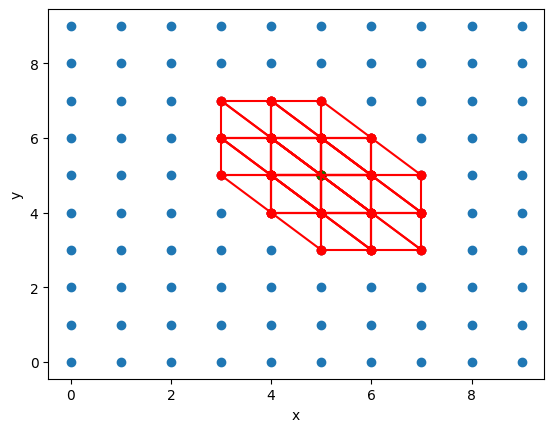

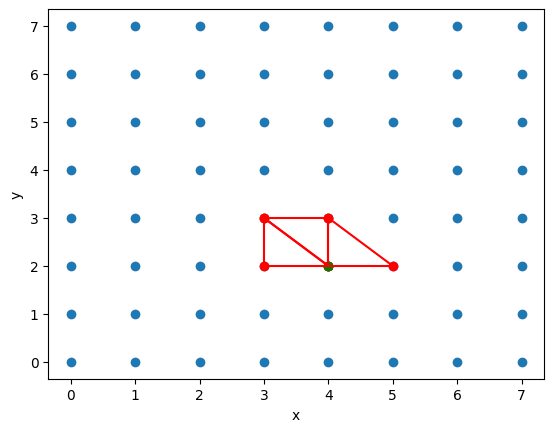

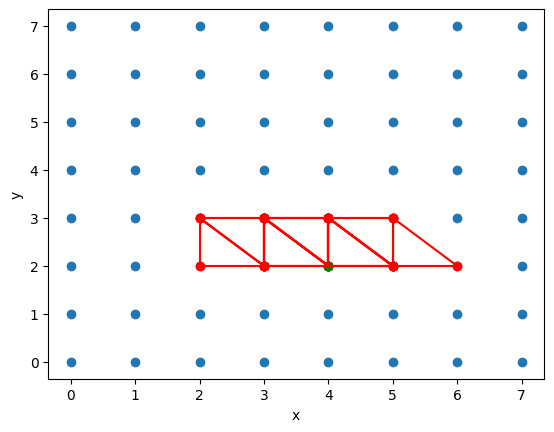

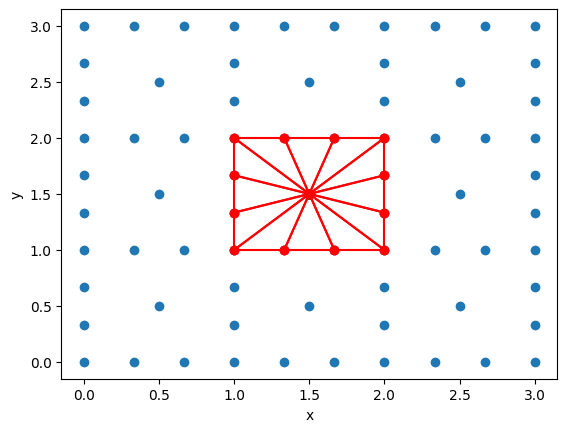

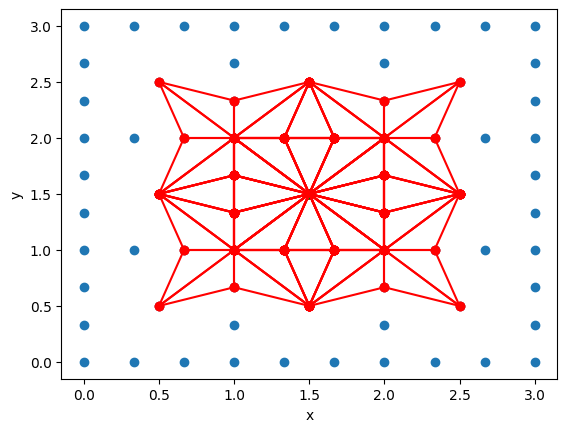

In [71]:
pairs_for_vis_point = [('siatka.txt', 3),
              ('big_siatka.txt', 55),
              ('pasek.txt', 20),
              ('gwiazdy.txt', 45)]

for file, point in pairs_for_vis_point:
    points, triangles = load_mesh(file)
    visualize_surrounding_points_list(points, triangles, point)
    visualize_surrounding_points_list(points, triangles, point, 2)

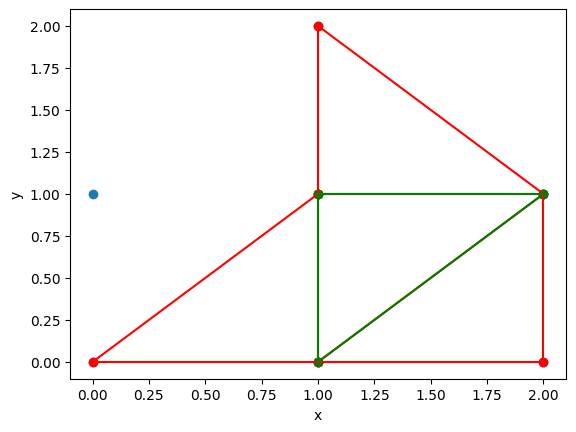

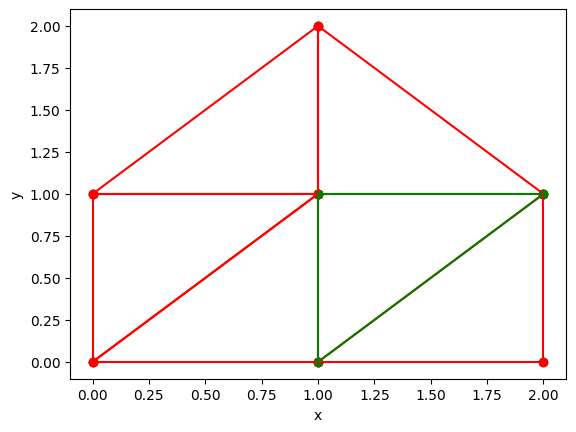

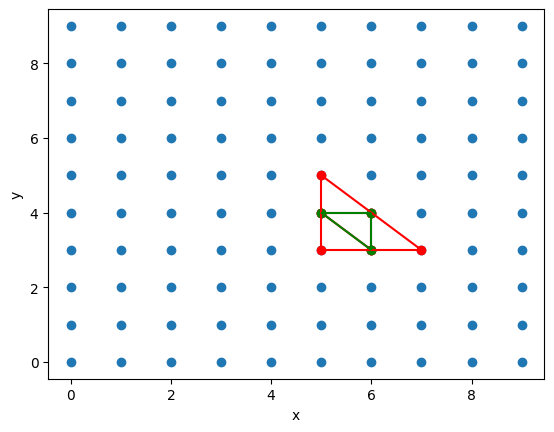

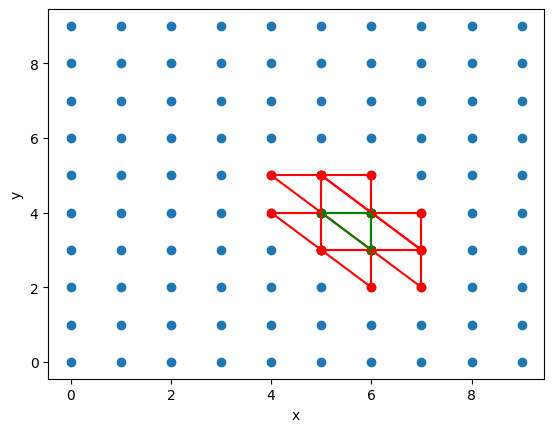

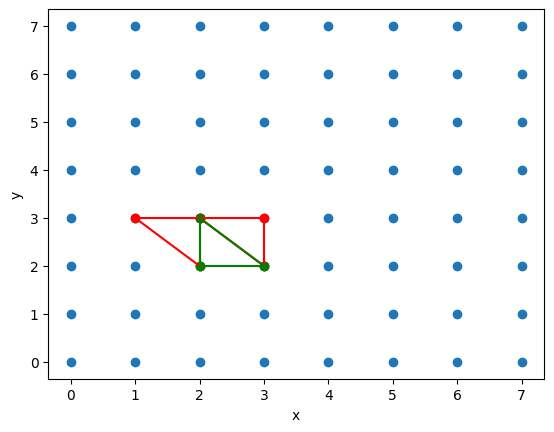

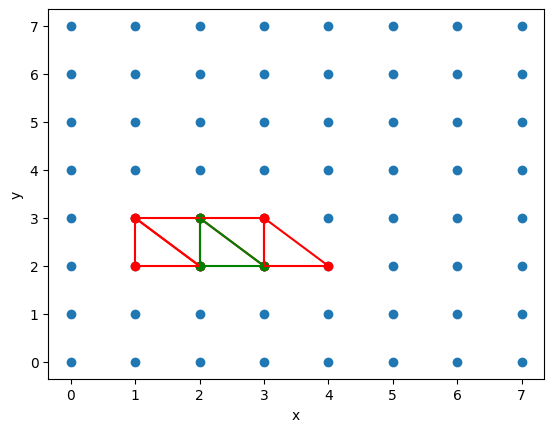

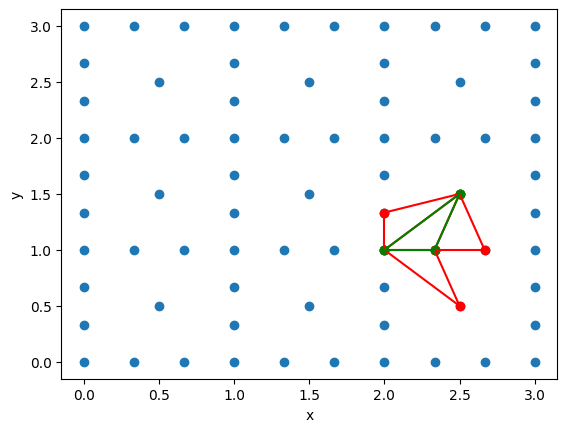

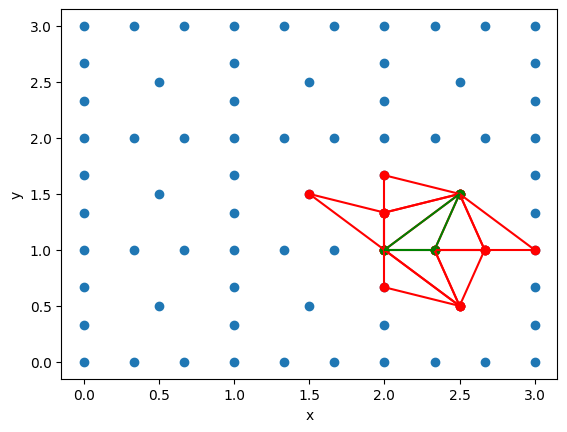

In [72]:
pairs_for_vis_triangle = [('siatka.txt', 3),
              ('big_siatka.txt', 65),
              ('pasek.txt', 20),
              ('gwiazdy.txt', 60)]

for file, tri in pairs_for_vis_triangle:
    points, triangles = load_mesh(file)
    visualize_surrounding_triangles_list(points, triangles, tri)
    visualize_surrounding_triangles_list(points, triangles, tri, 2)

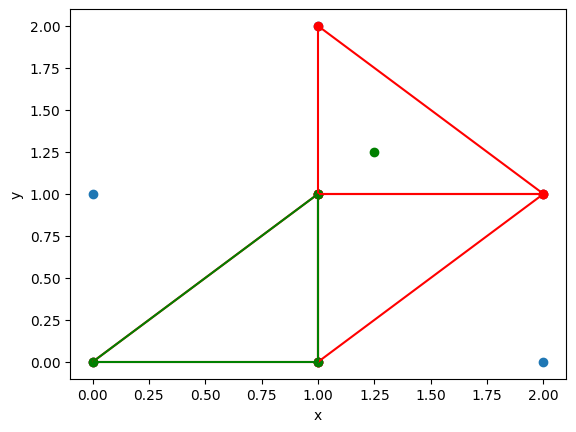

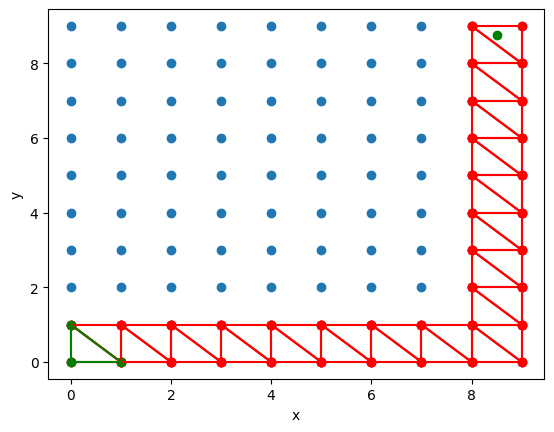

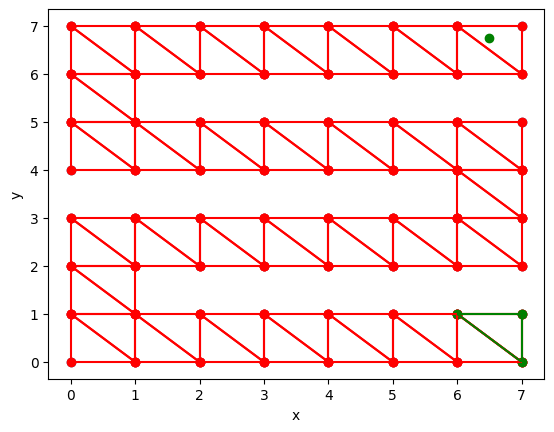

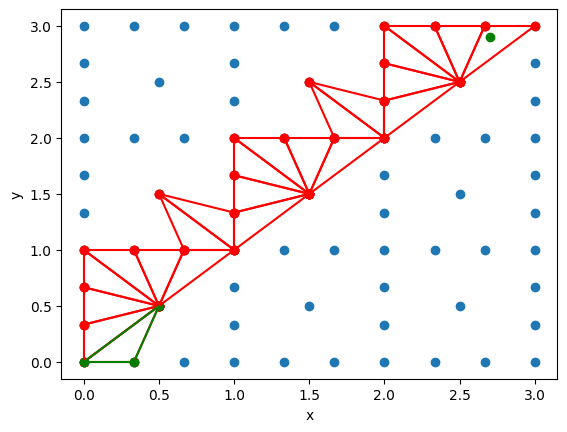

In [73]:
pairs_for_vis_search = [('siatka.txt', 0, (1.25, 1.25)),
              ('big_siatka.txt', 0,  (8.5, 8.75)),
              ('pasek.txt', 13, (6.5, 6.75)),
              ('gwiazdy.txt', 0, (2.7, 2.9))]

for file, tri, point in pairs_for_vis_search:
    points, triangles = load_mesh(file)
    visualize_point_in_mesh_list(points, triangles, tri, point)

In [74]:
vis = visualize_point_in_mesh_list(points_gwiazdy, triangles_gwiazdy, 0, (2.7, 2.9), show_gif=True)
vis.save_gif("gwiazdy_search.gif")

AttributeError: 'NoneType' object has no attribute 'save_gif'

# Testy szybkości algorytmów

## Testy funkcji znajdującej otoczenie punktu

In [75]:
test_input = [('siatka.txt', 3, 10**6),
              ('big_siatka.txt', 55, 10**5),
              ('pasek.txt', 20, 10**5),
              ('gwiazdy.txt', 45, 10**5)]

test_1_1_data = {'lists' : [], 'structure' : []}

for file, triangle_idx, num in test_input:
    input_points, input_triangles = load_mesh(file)
    structure = HalfEdgeDataStructure(input_points, input_triangles)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_points_list(input_points, input_triangles, triangle_idx)
    test_1_1_data['lists'].append(time.time() - time_start)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_points_structure(structure, triangle_idx)
    test_1_1_data['structure'].append(time.time() - time_start)

test_1_2_data = {'lists' : [], 'structure' : []}

for file, triangle_idx, num in test_input:
    input_points, input_triangles = load_mesh(file)
    structure = HalfEdgeDataStructure(input_points, input_triangles)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_points_list(input_points, input_triangles, triangle_idx, 2)
    test_1_2_data['lists'].append(time.time() - time_start)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_points_structure(structure, triangle_idx, 2)
    test_1_2_data['structure'].append(time.time() - time_start)


KeyboardInterrupt: 

## Testy funkcji znajdującej otoczenie trójkąta

In [ ]:
visualize_surrounding_triangles_structure(gwiazdy_structure, 60, 2)

In [288]:
test_input = [('siatka.txt', 3, 10**6),
              ('big_siatka.txt', 65, 10**5),
              ('pasek.txt', 20, 10**5),
              ('gwiazdy.txt', 60, 10**5)]

test_2_1_data = {'lists' : [], 'structure' : []}

for file, triangle_idx, num in test_input:
    input_points, input_triangles = load_mesh(file)
    structure = HalfEdgeDataStructure(input_points, input_triangles)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_triangles_list(input_points, input_triangles, triangle_idx)
    test_2_1_data['lists'].append(time.time() - time_start)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_triangles_structure(structure, triangle_idx)
    test_2_1_data['structure'].append(time.time() - time_start)

test_2_2_data = {'lists' : [], 'structure' : []}

for file, triangle_idx, num in test_input:
    input_points, input_triangles = load_mesh(file)
    structure = HalfEdgeDataStructure(input_points, input_triangles)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_triangles_list(input_points, input_triangles, triangle_idx, 2)
    test_2_2_data['lists'].append(time.time() - time_start)

    time_start = time.time()
    for _ in range(num):
        find_surrounding_triangles_structure(structure, triangle_idx, 2)
    test_2_2_data['structure'].append(time.time() - time_start)

{'lists': [5.547523498535156, 9.488869905471802, 3.7606382369995117, 6.4734625816345215], 'structure': [3.6557607650756836, 0.411435604095459, 0.2668900489807129, 0.37939882278442383]}
{'lists': [7.915017366409302, 10.848190069198608, 5.00387167930603, 10.087841987609863], 'structure': [7.372476816177368, 0.9115426540374756, 0.8450336456298828, 0.9104444980621338]}


## Testy funkcji szukających punktu w siatce

In [216]:
visualize_point_in_mesh_structure(gwiazdy_structure, 0, (2.7, 2.9), show_gif=True)

In [316]:
test_input = [('siatka.txt', 0, (1.25, 1.25), 10**5),
              ('big_siatka.txt', 0,  (8.5, 8.75), 10**5),
              ('pasek.txt', 13, (6.5, 6.75), 10**5),
              ('gwiazdy.txt', 0, (2.7, 2.9), 10**5)]

test_3_data = {'lists' : [], 'structure' : []}

for file, start_tri, point, num in test_input:
    input_points, input_triangles = load_mesh(file)
    structure = HalfEdgeDataStructure(input_points, input_triangles)

    time_start = time.time()
    for _ in range(num):
        find_point_in_mesh_list(input_points, input_triangles, start_tri, point)
    test_3_data['lists'].append(time.time() - time_start)

    time_start = time.time()
    for _ in range(num):
        find_point_in_mesh_structure(structure, start_tri, point)
    test_3_data['structure'].append(time.time() - time_start)


## Podsumowanie

In [317]:
all_data = [test_1_1_data, test_1_2_data, test_2_1_data, test_2_2_data, test_3_data]
row_labels = ['siatka', 'big_siatka', 'pasek', 'gwiazdy']
row_keys = [
    'szukanie otoczenia punktu w siatce; 1 warstwa',
    'szukanie otoczenia punktu w siatce; 2 warstwy',
    'szukanie otoczenia trójkąta w siatce; 1 warstwa',
    'szukanie otoczenia trójkąta w siatce; 2 warstwy',
    'wyszukiwanie punktu w siatce',
]

df = pd.concat([pd.DataFrame(d, index=row_labels) for d in all_data], keys=row_keys)
df.index.names = ['Operacja', 'Wejście']

df['Różnica bezwzględna [s]'] = df['lists'] - df['structure']

df['Różnica procentowa [%]'] = (df['Różnica bezwzględna [s]'] / df['lists']) * 100

df = df.round(4)

df.to_csv('testy_czasowe.csv')

print(df)

                                                              lists  \
Operacja                                        Wejście               
szukanie otoczenia punktu w siatce; 1 warstwa   siatka       0.7264   
szukanie otoczenia punktu w siatce; 1 warstwa   big_siatka  40.6646   
szukanie otoczenia punktu w siatce; 1 warstwa   pasek       17.4264   
szukanie otoczenia punktu w siatce; 1 warstwa   gwiazdy     14.2416   
szukanie otoczenia punktu w siatce; 2 warstwy   siatka       3.8434   
szukanie otoczenia punktu w siatce; 2 warstwy   big_siatka   6.2357   
szukanie otoczenia punktu w siatce; 2 warstwy   pasek        2.5894   
szukanie otoczenia punktu w siatce; 2 warstwy   gwiazdy      4.3492   
szukanie otoczenia trójkąta w siatce; 1 warstwa siatka       5.5475   
szukanie otoczenia trójkąta w siatce; 1 warstwa big_siatka   9.4889   
szukanie otoczenia trójkąta w siatce; 1 warstwa pasek        3.7606   
szukanie otoczenia trójkąta w siatce; 1 warstwa gwiazdy      6.4735   
szukan

In [76]:
## Testy pamięciowe

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [77]:
import gc
import tracemalloc
import statistics
import pandas as pd

def measure_peak_memory(func, *args, repeats=7, warmup=2):
    """
    Zwraca medianę peak memory (w bajtach) podczas wykonywania func(*args).
    Mierzy alokacje Pythona (peak z tracemalloc).
    """
    # rozgrzewka (bez pomiaru)
    for _ in range(warmup):
        func(*args)

    peaks = []
    for _ in range(repeats):
        gc.collect()
        tracemalloc.start()
        func(*args)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak)

    return statistics.median(peaks)

def kib(x_bytes):
    return x_bytes / 1024.0

# Parametry jak w testach czasu
DATASETS = [
    ("Zbiór A", "siatka.txt"),
    ("Zbiór B", "big_siatka.txt"),
    ("Zbiór C", "pasek.txt"),
    ("Zbiór D", "gwiazdy.txt"),
]

# OP1
OP1_POINT_IDX = {
    "siatka.txt": 3,
    "big_siatka.txt": 55,
    "pasek.txt": 20,
    "gwiazdy.txt": 45,
}

# OP2
OP2_TRI_IDX = {
    "siatka.txt": 3,
    "big_siatka.txt": 65,
    "pasek.txt": 20,
    "gwiazdy.txt": 60,
}

# OP3
OP3_PARAMS = {
    "siatka.txt": (0, (1.25, 1.25)),
    "big_siatka.txt": (0, (8.5, 8.75)),
    "pasek.txt": (13, (6.5, 6.75)),
    "gwiazdy.txt": (0, (2.7, 2.9)),
}

rows = []

for label, file in DATASETS:
    points, triangles = load_mesh(file)
    structure = HalfEdgeDataStructure(points, triangles)

    # OP1
    pidx = OP1_POINT_IDX[file]

    peak_list = measure_peak_memory(find_surrounding_points_list, points, triangles, pidx, 1)
    peak_heds = measure_peak_memory(find_surrounding_points_structure, structure, pidx, 1)

    rows.append({
        "Operacja": "OP1; 1 warstwa",
        "Wejście": label,
        "Peak lista [KiB]": kib(peak_list),
        "Peak HEDS [KiB]": kib(peak_heds),
        "Różnica [KiB]": kib(peak_list - peak_heds),
        "Różnica procentowa [%]": ((peak_list - peak_heds) / peak_list * 100.0) if peak_list else 0.0,
    })

    # OP1
    peak_list = measure_peak_memory(find_surrounding_points_list, points, triangles, pidx, 2)
    peak_heds = measure_peak_memory(find_surrounding_points_structure, structure, pidx, 2)

    rows.append({
        "Operacja": "OP1; 2 warstwy",
        "Wejście": label,
        "Peak lista [KiB]": kib(peak_list),
        "Peak HEDS [KiB]": kib(peak_heds),
        "Różnica [KiB]": kib(peak_list - peak_heds),
        "Różnica procentowa [%]": ((peak_list - peak_heds) / peak_list * 100.0) if peak_list else 0.0,
    })

    # OP2
    tidx = OP2_TRI_IDX[file]

    peak_list = measure_peak_memory(find_surrounding_triangles_list, points, triangles, tidx, 1)
    peak_heds = measure_peak_memory(find_surrounding_triangles_structure, structure, tidx, 1)

    rows.append({
        "Operacja": "OP2; 1 warstwa",
        "Wejście": label,
        "Peak lista [KiB]": kib(peak_list),
        "Peak HEDS [KiB]": kib(peak_heds),
        "Różnica [KiB]": kib(peak_list - peak_heds),
        "Różnica procentowa [%]": ((peak_list - peak_heds) / peak_list * 100.0) if peak_list else 0.0,
    })

    # OP2
    peak_list = measure_peak_memory(find_surrounding_triangles_list, points, triangles, tidx, 2)
    peak_heds = measure_peak_memory(find_surrounding_triangles_structure, structure, tidx, 2)

    rows.append({
        "Operacja": "OP2; 2 warstwy",
        "Wejście": label,
        "Peak lista [KiB]": kib(peak_list),
        "Peak HEDS [KiB]": kib(peak_heds),
        "Różnica [KiB]": kib(peak_list - peak_heds),
        "Różnica procentowa [%]": ((peak_list - peak_heds) / peak_list * 100.0) if peak_list else 0.0,
    })

    # OP3
    start_tri, end_point = OP3_PARAMS[file]

    def op3_list_wrapper():
        tri_copy = [tuple(t) for t in triangles]
        return find_point_in_mesh_list(points, tri_copy, start_tri, end_point)

    peak_list = measure_peak_memory(op3_list_wrapper)
    peak_heds = measure_peak_memory(find_point_in_mesh_structure, structure, start_tri, end_point)

    rows.append({
        "Operacja": "OP3",
        "Wejście": label,
        "Peak lista [KiB]": kib(peak_list),
        "Peak HEDS [KiB]": kib(peak_heds),
        "Różnica [KiB]": kib(peak_list - peak_heds),
        "Różnica procentowa [%]": ((peak_list - peak_heds) / peak_list * 100.0) if peak_list else 0.0,
    })

df_mem = pd.DataFrame(rows)

# formatowanie pod czytelny wydruk
df_mem["Peak lista [KiB]"] = df_mem["Peak lista [KiB]"].map(lambda x: round(x, 4))
df_mem["Peak HEDS [KiB]"] = df_mem["Peak HEDS [KiB]"].map(lambda x: round(x, 4))
df_mem["Różnica [KiB]"] = df_mem["Różnica [KiB]"].map(lambda x: round(x, 4))
df_mem["Różnica procentowa [%]"] = df_mem["Różnica procentowa [%]"].map(lambda x: round(x, 4))

display(df_mem)

# zapis jak w testach czasu
df_mem.to_csv("testy_pamieciowe.csv", index=False)
print("Zapisano: testy_pamieciowe.csv")

,Operacja,Wejście,Peak lista [KiB],Peak HEDS [KiB],Różnica [KiB],Różnica procentowa [%]
0,OP1; 1 warstwa,Zbiór A,3.3672,1.5781,1.7891,53.1323
1,OP1; 2 warstwy,Zbiór A,3.9531,2.9297,1.0234,25.8893
2,OP2; 1 warstwa,Zbiór A,3.7578,2.2266,1.5312,40.7484
3,OP2; 2 warstwy,Zbiór A,4.5625,3.4844,1.0781,23.6301
4,OP3,Zbiór A,3.1016,0.4844,2.6172,84.3829
5,OP1; 1 warstwa,Zbiór B,59.7188,2.9609,56.7578,95.0419
6,OP1; 2 warstwy,Zbiór B,62.3359,5.5781,56.7578,91.0515
7,OP2; 1 warstwa,Zbiór B,47.2422,2.2266,45.0156,95.2869
8,OP2; 2 warstwy,Zbiór B,48.5781,3.8594,44.7188,92.0553
9,OP3,Zbiór B,66.3125,2.9375,63.3750,95.5702


Zapisano: testy_pamieciowe.csv
